In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [34]:
# # マージ
# # 各ランを読み込み、辞書に追加
# # ランナンバーも追加
# # GRX, GRY, LASX, LASYが-9999も削除

# run_list = [2025, 2026]
# dfs = {}  # 空の辞書を作成

# for run in run_list:
#     file_name = f'run{run}_none.csv'
#     df = pd.read_csv(file_name)

#     xdp=df['GRX']
#     adp=df['GRA']
#     ydp=df['GRY']
#     bdp=df['GRB']
#     GRQ2=df['GRQ2charge']

#     df = df[
#         (xdp!=-9999) & (ydp!=-9999)
#     ]

#     LASX = df['LASX']
#     LASA = df['LASA']
#     LASY = df['LASY']
#     LASB = df['LASB']

#     df = df[
#         (LASX!=-9999) & (LASY!=-9999)
#     ]

#     df.insert(0, 'run', run)

#     # 辞書に格納 (キーをRun番号にする)
#     dfs[run] = df

# # 呼び出すときは dfs[2025] のようにします
# # print(dfs[2025].head())


# # データを読み込み、すべての列を数値型に変換
# data = pd.read_csv("run2025_none.csv")


# GRtiming=data['GRQ2timing']
# LAStiming=data['LASQ1timing']
# TDiff=LAStiming-GRtiming

In [35]:
# # dfsを結合
# # (ここはすでにdfsが作成されている前提です)
# # dfs = {2025: df_2025, 2005: df_2005, ...} 

# # 1. 結合用のリストを作成
# list_of_dfs = []

# # 2. 辞書から一つずつ取り出して処理
# for run_num, df in dfs.items():
#     # 元のデータを壊さないようにコピー
#     df_temp = df.copy()
    
#     # リストに追加
#     list_of_dfs.append(df_temp)

# # 3. 全てを縦に結合 (concat)
# correct = pd.concat(list_of_dfs, ignore_index=True)

In [36]:
correct = pd.read_csv("C_labeled.csv")

In [37]:
GRQ2_track = correct['GRQ2charge']

TOT=correct['LASTOT']
Lx=correct['LASX']
GRtiming=correct['GRQ2timing']
LAStiming=correct['LASQ1timing']
TDiff=LAStiming-GRtiming

#PID
PID_gated = correct[
    # (GRQ2_track > 213.276 - 21.194 * 5) & (GRQ2_track < 213.276 + 21.194 * 5) & (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)>140) & (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)<170)
    (GRQ2_track > 213.276 - 21.194 * 5) & (GRQ2_track < 213.276 + 21.194 * 5) & (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)>140) & (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)<170)
]

TOT_alpha=PID_gated['LASTOT']
Lx_alpha=PID_gated['LASX']
GRtiming_alpha=PID_gated['GRQ2timing']
LAStiming_alpha=PID_gated['LASQ1timing']
TDiff_alpha=LAStiming_alpha-GRtiming_alpha

#Tp, Ta制限
# --- 物理量の計算 ---
GRX = PID_gated['GRX']
LASX = PID_gated['LASX']
LASA = PID_gated['LASA']

# Tp, Tαの計算
Tp = (((GRX * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
LASX_f = LASA * (-2.57 * Tp + 1274.57) + LASX
T_alpha_f = 0.02746 * LASX_f + 63.804

PID_gated = PID_gated[
    (Tp > 305) & (Tp < 330) & (T_alpha_f > 55) & (T_alpha_f < 80)
]

In [38]:
# true coincidenceのヒストグラム
#コインシデンスゲート
true = PID_gated[
    (TDiff_alpha >= 50) & (TDiff_alpha < 110)
]

# ヒストグラムの設定
hist_min = -100
hist_max = 100
bin_width = 1
bins = np.arange(hist_min, hist_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# --- 物理量の計算 ---
GRX_acc = true['GRX']
LASX_acc = true['LASX']
LASA_acc = true['LASA']

# Tp, Tαの計算
Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
# Variable (S_alpha)
variable = 392 - Tp_acc - T_alpha_acc_f

# --- ヒストグラム作成 (カウントのみ取得) ---
counts2, _ = np.histogram(variable, bins=bins)
    
# リストに追加
hist_list2 = []
hist_list2.append(counts2)

/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_8462/2314831593.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  true = PID_gated[


In [39]:
# `from matplotlib.colors import Normalize
# #input
# ####################################################
# #variables
# x_axis_variable=LASX_acc_f
# y_axis_variable=TOT
# #hist range
# x_axis_range_min = -1000
# x_axis_range_max = 1000
# y_axis_range_min = 0
# y_axis_range_max = 300
# #bin width
# x_bin_width=1
# y_bin_width=1
# ######################################################

# # ヒストグラムを作成
# bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
#         np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
# hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# # 図の準備
# fig, ax = plt.subplots(figsize=(8, 6))
# # ヒートマップの作成（カウントに応じて色付け）
# norm = Normalize(vmin=0, vmax=np.max(hist) // 2)  # 色の範囲を細かく調整
# mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# # カラーバーを追加
# cbar = plt.colorbar(mesh, ax=ax)
# cbar.set_label('Counts')

# # 軸範囲とグリッド
# # ax.set_xlabel('T_alpha[MeV]')
# # ax.set_ylabel('Tp[MeV]')
# ax.grid()`

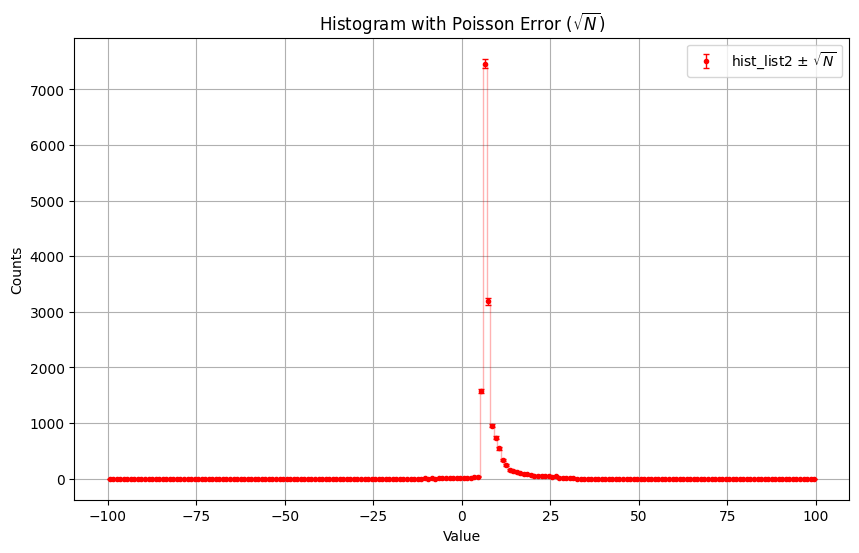

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# --- 事前準備 (hist_list2 と bins は作成済みと仮定) ---
# hist_list2: ヒストグラムのカウント数配列 (1次元)
# bins: ビンの境界配列

# ビンの中心を計算
bin_centers = (bins[:-1] + bins[1:]) / 2

# もし hist_list2 がリストの中に入っている場合 ([array(...)]) は取り出す
# hist_list2 = hist_list2[0] 

# --- 1. 誤差の計算 (ルートN) ---
# カウント数の平方根を計算
error2 = np.sqrt(hist_list2[0])

# --- 2. プロット ---
fig, ax = plt.subplots(figsize=(10, 6))

# エラーバー付きでプロット
# fmt='o' で点として描画し、エラーバーを付けます
ax.errorbar(bin_centers, hist_list2[0], yerr=error2, 
            fmt='o', markersize=3, capsize=2, linewidth=1, color='red',
            label='hist_list2 ± $\sqrt{N}$')

# 形状を見やすくするために、薄くステップ状の線も重ねて描くのが一般的です
ax.step(bin_centers, hist_list2[0], where='mid', color='red', alpha=0.3, linewidth=1)

ax.set_xlabel('Value')
ax.set_ylabel('Counts')
ax.set_title('Histogram with Poisson Error ($\sqrt{N}$)')
ax.legend()
ax.grid(True)

plt.show()
plt.show()

Text(0, 0.5, 'counts')

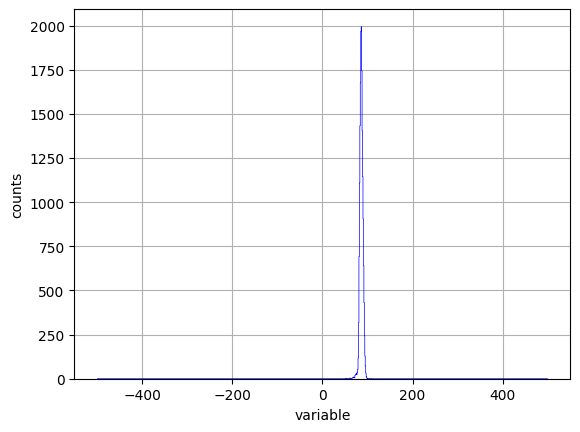

In [41]:
#アルファゲートかけてコインシデンスとる
#綺麗にアクシデンタル減らせたのを確認

import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable = true['LASQ1timing'] - true['GRQ2timing']
#hist range
range_min=-500
range_max=500
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

In [42]:
bin_centers

array([-499.5, -498.5, -497.5, -496.5, -495.5, -494.5, -493.5, -492.5,
       -491.5, -490.5, -489.5, -488.5, -487.5, -486.5, -485.5, -484.5,
       -483.5, -482.5, -481.5, -480.5, -479.5, -478.5, -477.5, -476.5,
       -475.5, -474.5, -473.5, -472.5, -471.5, -470.5, -469.5, -468.5,
       -467.5, -466.5, -465.5, -464.5, -463.5, -462.5, -461.5, -460.5,
       -459.5, -458.5, -457.5, -456.5, -455.5, -454.5, -453.5, -452.5,
       -451.5, -450.5, -449.5, -448.5, -447.5, -446.5, -445.5, -444.5,
       -443.5, -442.5, -441.5, -440.5, -439.5, -438.5, -437.5, -436.5,
       -435.5, -434.5, -433.5, -432.5, -431.5, -430.5, -429.5, -428.5,
       -427.5, -426.5, -425.5, -424.5, -423.5, -422.5, -421.5, -420.5,
       -419.5, -418.5, -417.5, -416.5, -415.5, -414.5, -413.5, -412.5,
       -411.5, -410.5, -409.5, -408.5, -407.5, -406.5, -405.5, -404.5,
       -403.5, -402.5, -401.5, -400.5, -399.5, -398.5, -397.5, -396.5,
       -395.5, -394.5, -393.5, -392.5, -391.5, -390.5, -389.5, -388.5,
      

In [43]:
hist_list2

[array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    1,    2,    1,    1,    2,
           2,    5,    2,    7,    1,    7,    5,    6,    4,   10,    6,
           7,   15,   13,   19,   29,   38, 1581, 7466, 3187,  956,  734,
         544,  343,  242,  156,  139,  115,   99,   82,   77,   68,   41,
          53,   51,   48,   42,   32,   41,   21,   20,   10,   11,    4,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0, 

In [44]:
# # -250から50まで
# import numpy as np
# import matplotlib.pyplot as plt

# # --- 1. 設定パラメータ ---
# window_width = 60       # TDiffのウィンドウ幅
# start_tdiff = -250      # 開始位置
# end_tdiff = 50         # 終了位置

# # ヒストグラムの設定（全てのウィンドウで共通にする必要があります）
# hist_min = -100
# hist_max = 100
# bin_width = 1
# bins = np.arange(hist_min, hist_max + bin_width, bin_width)
# bin_centers = (bins[:-1] + bins[1:]) / 2

# # ヒストグラムデータを格納するリスト
# hist_list = []

# # --- 2. ループ処理で各範囲のヒストグラムを取得 ---
# for t_start in range(start_tdiff, end_tdiff, window_width):
#     t_end = t_start + window_width
    
#     # データの抽出
#     subset = PID_gated[
#         (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
#     ]
    
#     # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
#     if len(subset) < 10:
#         continue

#     # --- 物理量の計算 ---
#     GRX_acc = subset['GRX']
#     LASX_acc = subset['LASX']
#     LASA_acc = subset['LASA']

#     # Tp, Tαの計算
#     Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
#     LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
#     T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
#     # Variable (S_alpha)
#     variable = 392 - Tp_acc - T_alpha_acc_f

#     # --- ヒストグラム作成 (カウントのみ取得) ---
#     counts, _ = np.histogram(variable, bins=bins)
    
#     # リストに追加
#     hist_list.append(counts)

# # --- 3. 平均と標準偏差の計算 ---

# # リストをNumPy配列（行列）に変換
# # 行: 各TDiffウィンドウ, 列: 各ビン
# hist_matrix = np.array(hist_list)

# # サンプル数（ウィンドウの数）
# N_samples = hist_matrix.shape[0]

# print(f"Number of stacked windows: {N_samples}")

# if N_samples > 0:
#     # 縦方向 (axis=0) に計算
    
#     # 平均スペクトル
#     mean_spectrum = np.mean(hist_matrix, axis=0)
    
#     # 標準偏差 (Standard Deviation)
#     # ddof=1 は不偏標準偏差（サンプル数が少ない場合に推奨）
#     std_spectrum = np.std(hist_matrix, axis=0, ddof=1)

#     # --- 4. プロット ---
#     fig, ax = plt.subplots(figsize=(10, 6))
    
#     # エラーバー付きで平均スペクトルをプロット
#     # yerr に標準偏差を指定することで、ばらつきを表示
#     ax.errorbar(bin_centers, mean_spectrum, yerr=std_spectrum, 
#                 fmt='-o', markersize=3, capsize=2, linewidth=1, color='blue',
#                 label='Averaged Spectrum ± StdDev')
    
#     # 参考までに個別のスペクトルを薄く表示（ばらつき具合を目視するため）
#     for i in range(N_samples):
#         ax.step(bin_centers, hist_matrix[i], where='mid', color='gray', alpha=0.2, linewidth=0.5)

#     ax.set_xlabel('$S_\\alpha$ Value')
#     ax.set_ylabel('Average Counts')
#     ax.set_title(f'Averaged Spectrum over {N_samples} Time Windows')
#     ax.set_ylim(0, 200)
#     ax.grid(True)
#     ax.legend()
    
#     plt.show()

# else:
#     print("No valid data found in the specified ranges.")

In [45]:

# # ヒストグラムの設定（全てのウィンドウで共通にする必要があります）
# hist_min = -100
# hist_max = 100
# bin_width = 1
# bins = np.arange(hist_min, hist_max + bin_width, bin_width)
# bin_centers = (bins[:-1] + bins[1:]) / 2

# # ヒストグラムデータを格納するリスト
# hist_list = []

# # --- 2. ループ処理で各範囲のヒストグラムを取得 ---
# for t_start in range(start_tdiff, end_tdiff, window_width):
#     t_end = t_start + window_width
    
#     # データの抽出
#     subset = PID_gated[
#         (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
#     ]
    
#     # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
#     if len(subset) < 10:
#         continue

#     # --- 物理量の計算 ---
#     GRX_acc = subset['GRX']
#     LASX_acc = subset['LASX']
#     LASA_acc = subset['LASA']

#     # Tp, Tαの計算
#     Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
#     LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
#     T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
#     # Variable (S_alpha)
#     variable = 392 - Tp_acc - T_alpha_acc_f

#     # --- ヒストグラム作成 (カウントのみ取得) ---
#     counts, _ = np.histogram(variable, bins=bins)
    
#     # リストに追加
#     hist_list.append(counts)

# # --- 3. 平均と標準偏差の計算 ---

# # リストをNumPy配列（行列）に変換
# # 行: 各TDiffウィンドウ, 列: 各ビン
# hist_matrix = np.array(hist_list)

# # サンプル数（ウィンドウの数）
# N_samples = hist_matrix.shape[0]

# print(f"Number of stacked windows: {N_samples}")

# if N_samples > 0:
#     # 縦方向 (axis=0) に計算
    
#     # 平均スペクトル
#     mean_spectrum = np.mean(hist_matrix, axis=0)
    
#     # 標準偏差 (Standard Deviation)
#     # ddof=1 は不偏標準偏差（サンプル数が少ない場合に推奨）
#     std_spectrum = np.std(hist_matrix, axis=0, ddof=1)

#     # --- 4. プロット ---
#     fig, ax = plt.subplots(figsize=(10, 6))
    
#     # エラーバー付きで平均スペクトルをプロット
#     # yerr に標準偏差を指定することで、ばらつきを表示
#     ax.errorbar(bin_centers, mean_spectrum, yerr=std_spectrum, 
#                 fmt='-o', markersize=3, capsize=2, linewidth=1, color='blue',
#                 label='Averaged Spectrum ± StdDev')
    
#     # 参考までに個別のスペクトルを薄く表示（ばらつき具合を目視するため）
#     for i in range(N_samples):
#         ax.step(bin_centers, hist_matrix[i], where='mid', color='gray', alpha=0.2, linewidth=0.5)

#     ax.set_xlabel('$S_\\alpha$ Value')
#     ax.set_ylabel('Average Counts')
#     ax.set_title(f'Averaged Spectrum over {N_samples} Time Windows')
#     ax.set_ylim(0, 200)
#     ax.grid(True)
#     ax.legend()
    
#     plt.show()

# else:
#     print("No valid data found in the specified ranges.")

In [46]:
# hist_min = -100
# hist_max = 100
# bin_width = 1
# bins = np.arange(hist_min, hist_max + bin_width, bin_width)
# bin_centers = (bins[:-1] + bins[1:]) / 2

# # ヒストグラムデータを格納するリスト
# hist_list = []

# # --- 2. ループ処理で各範囲のヒストグラムを取得 ---
# for t_start in range(start_tdiff, end_tdiff, window_width):
#     t_end = t_start + window_width
    
#     # データの抽出
#     subset = PID_gated[
#         (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
#     ]
    
#     # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
#     if len(subset) < 10:
#         continue

#     # --- 物理量の計算 ---
#     GRX_acc = subset['GRX']
#     LASX_acc = subset['LASX']
#     LASA_acc = subset['LASA']

#     # Tp, Tαの計算
#     Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
#     LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
#     T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
#     # Variable (S_alpha)
#     variable = 392 - Tp_acc - T_alpha_acc_f

#     # --- ヒストグラム作成 (カウントのみ取得) ---
#     counts, _ = np.histogram(variable, bins=bins)
    
#     # リストに追加
#     hist_list.append(counts)

# # --- 3. 平均と標準偏差の計算 ---

# # リストをNumPy配列（行列）に変換
# # 行: 各TDiffウィンドウ, 列: 各ビン
# hist_matrix = np.array(hist_list)

# # サンプル数（ウィンドウの数）
# N_samples = hist_matrix.shape[0]

# print(f"Number of stacked windows: {N_samples}")

# if N_samples > 0:
#     # 縦方向 (axis=0) に計算
    
#     # 平均スペクトル
#     mean_spectrum = np.mean(hist_matrix, axis=0)
    
#     # 標準偏差 (Standard Deviation)
#     # ddof=1 は不偏標準偏差（サンプル数が少ない場合に推奨）
#     std_spectrum = np.std(hist_matrix, axis=0, ddof=1)

#     # --- 4. プロット ---
#     fig, ax = plt.subplots(figsize=(10, 6))
    
#     # エラーバー付きで平均スペクトルをプロット
#     # yerr に標準偏差を指定することで、ばらつきを表示
#     ax.errorbar(bin_centers, mean_spectrum, yerr=std_spectrum, 
#                 fmt='-o', markersize=3, capsize=2, linewidth=1, color='blue',
#                 label='Averaged Spectrum ± StdDev')
    
#     # 参考までに個別のスペクトルを薄く表示（ばらつき具合を目視するため）
#     for i in range(N_samples):
#         ax.step(bin_centers, hist_matrix[i], where='mid', color='gray', alpha=0.2, linewidth=0.5)

#     ax.set_xlabel('$S_\\alpha$ Value')
#     ax.set_ylabel('Average Counts')
#     ax.set_title(f'Averaged Spectrum over {N_samples} Time Windows')
#     ax.set_ylim(0, 200)
#     ax.grid(True)
#     ax.legend()
    
#     plt.show()

# else:
#     print("No valid data found in the specified ranges.")

In [47]:
# hist_max = 100
# bin_width = 1
# bins = np.arange(hist_min, hist_max + bin_width, bin_width)
# bin_centers = (bins[:-1] + bins[1:]) / 2

# # ヒストグラムデータを格納するリスト
# hist_list = []

# # --- 2. ループ処理で各範囲のヒストグラムを取得 ---
# for t_start in range(start_tdiff, end_tdiff, window_width):
#     t_end = t_start + window_width
    
#     # データの抽出
#     subset = PID_gated[
#         (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
#     ]
    
#     # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
#     if len(subset) < 10:
#         continue

#     # --- 物理量の計算 ---
#     GRX_acc = subset['GRX']
#     LASX_acc = subset['LASX']
#     LASA_acc = subset['LASA']

#     # Tp, Tαの計算
#     Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
#     LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
#     T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
#     # Variable (S_alpha)
#     variable = 392 - Tp_acc - T_alpha_acc_f

#     # --- ヒストグラム作成 (カウントのみ取得) ---
#     counts, _ = np.histogram(variable, bins=bins)
    
#     # リストに追加
#     hist_list.append(counts)

# # --- 3. 平均と標準偏差の計算 ---

# # リストをNumPy配列（行列）に変換
# # 行: 各TDiffウィンドウ, 列: 各ビン
# hist_matrix = np.array(hist_list)

# # サンプル数（ウィンドウの数）
# N_samples = hist_matrix.shape[0]

# print(f"Number of stacked windows: {N_samples}")

# if N_samples > 0:
#     # 縦方向 (axis=0) に計算
    
#     # 平均スペクトル
#     mean_spectrum = np.mean(hist_matrix, axis=0)
    
#     # 標準偏差 (Standard Deviation)
#     # ddof=1 は不偏標準偏差（サンプル数が少ない場合に推奨）
#     std_spectrum = np.std(hist_matrix, axis=0, ddof=1)

#     # --- 4. プロット ---
#     fig, ax = plt.subplots(figsize=(10, 6))
    
#     # エラーバー付きで平均スペクトルをプロット
#     # yerr に標準偏差を指定することで、ばらつきを表示
#     ax.errorbar(bin_centers, mean_spectrum, yerr=std_spectrum, 
#                 fmt='-o', markersize=3, capsize=2, linewidth=1, color='blue',
#                 label='Averaged Spectrum ± StdDev')
    
#     # 参考までに個別のスペクトルを薄く表示（ばらつき具合を目視するため）
#     for i in range(N_samples):
#         ax.step(bin_centers, hist_matrix[i], where='mid', color='gray', alpha=0.2, linewidth=0.5)

#     ax.set_xlabel('$S_\\alpha$ Value')
#     ax.set_ylabel('Average Counts')
#     ax.set_title(f'Averaged Spectrum over {N_samples} Time Windows')
#     ax.set_ylim(0, 200)
#     ax.grid(True)
#     ax.legend()
    
#     plt.show()

# else:
#     print("No valid data found in the specified ranges.")

In [48]:
# hist_max = 100
# bin_width = 1
# bins = np.arange(hist_min, hist_max + bin_width, bin_width)
# bin_centers = (bins[:-1] + bins[1:]) / 2

# # ヒストグラムデータを格納するリスト
# hist_list = []

# # --- 2. ループ処理で各範囲のヒストグラムを取得 ---
# for t_start in range(start_tdiff, end_tdiff, window_width):
#     t_end = t_start + window_width
    
#     # データの抽出
#     subset = PID_gated[
#         (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
#     ]
    
#     # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
#     if len(subset) < 10:
#         continue

#     # --- 物理量の計算 ---
#     GRX_acc = subset['GRX']
#     LASX_acc = subset['LASX']
#     LASA_acc = subset['LASA']

#     # Tp, Tαの計算
#     Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
#     LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
#     T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
#     # Variable (S_alpha)
#     variable = 392 - Tp_acc - T_alpha_acc_f

#     # --- ヒストグラム作成 (カウントのみ取得) ---
#     counts, _ = np.histogram(variable, bins=bins)
    
#     # リストに追加
#     hist_list.append(counts)

# # --- 3. 平均と標準偏差の計算 ---

# # リストをNumPy配列（行列）に変換
# # 行: 各TDiffウィンドウ, 列: 各ビン
# hist_matrix = np.array(hist_list)

# # サンプル数（ウィンドウの数）
# N_samples = hist_matrix.shape[0]

# print(f"Number of stacked windows: {N_samples}")

# if N_samples > 0:
#     # 縦方向 (axis=0) に計算
    
#     # 平均スペクトル
#     mean_spectrum = np.mean(hist_matrix, axis=0)
    
#     # 標準偏差 (Standard Deviation)
#     # ddof=1 は不偏標準偏差（サンプル数が少ない場合に推奨）
#     std_spectrum = np.std(hist_matrix, axis=0, ddof=1)

#     # --- 4. プロット ---
#     fig, ax = plt.subplots(figsize=(10, 6))
    
#     # エラーバー付きで平均スペクトルをプロット
#     # yerr に標準偏差を指定することで、ばらつきを表示
#     ax.errorbar(bin_centers, mean_spectrum, yerr=std_spectrum, 
#                 fmt='-o', markersize=3, capsize=2, linewidth=1, color='blue',
#                 label='Averaged Spectrum ± StdDev')
    
#     # 参考までに個別のスペクトルを薄く表示（ばらつき具合を目視するため）
#     for i in range(N_samples):
#         ax.step(bin_centers, hist_matrix[i], where='mid', color='gray', alpha=0.2, linewidth=0.5)

#     ax.set_xlabel('$S_\\alpha$ Value')
#     ax.set_ylabel('Average Counts')
#     ax.set_title(f'Averaged Spectrum over {N_samples} Time Windows')
#     ax.set_ylim(0, 200)
#     ax.grid(True)
#     ax.legend()
    
#     plt.show()

# else:
#     print("No valid data found in the specified ranges.")

In [49]:
# len(hist_list)

In [50]:
# # 110から410まで
# import numpy as np
# import matplotlib.pyplot as plt

# # --- 1. 設定パラメータ ---
# window_width = 60       # TDiffのウィンドウ幅
# start_tdiff = 110      # 開始位置
# end_tdiff = 410         # 終了位置

# # ヒストグラムの設定（全てのウィンドウで共通にする必要があります）
# hist_min = -100
# hist_max = 100
# bin_width = 1
# bins = np.arange(hist_min, hist_max + bin_width, bin_width)
# bin_centers = (bins[:-1] + bins[1:]) / 2

# # ヒストグラムデータを格納するリスト

# # --- 2. ループ処理で各範囲のヒストグラムを取得 ---
# for t_start in range(start_tdiff, end_tdiff, window_width):
#     t_end = t_start + window_width
    
#     # データの抽出
#     subset = PID_gated[
#         (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
#     ]
    
#     # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
#     if len(subset) < 10:
#         continue

#     # --- 物理量の計算 ---
#     GRX_acc = subset['GRX']
#     LASX_acc = subset['LASX']
#     LASA_acc = subset['LASA']

#     # Tp, Tαの計算
#     Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
#     LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
#     T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
#     # Variable (S_alpha)
#     variable = 392 - Tp_acc - T_alpha_acc_f

#     # --- ヒストグラム作成 (カウントのみ取得) ---
#     counts, _ = np.histogram(variable, bins=bins)
    
#     # リストに追加
#     hist_list.append(counts)

# # --- 3. 平均と標準偏差の計算 ---

# # リストをNumPy配列（行列）に変換
# # 行: 各TDiffウィンドウ, 列: 各ビン
# hist_matrix = np.array(hist_list)

# # サンプル数（ウィンドウの数）
# N_samples = hist_matrix.shape[0]

# print(f"Number of stacked windows: {N_samples}")

# if N_samples > 0:
#     # 縦方向 (axis=0) に計算
    
#     # 平均スペクトル
#     mean_spectrum = np.mean(hist_matrix, axis=0)
    
#     # 標準偏差 (Standard Deviation)
#     # ddof=1 は不偏標準偏差（サンプル数が少ない場合に推奨）
#     std_spectrum = np.std(hist_matrix, axis=0, ddof=1)

#     # --- 4. プロット ---
#     fig, ax = plt.subplots(figsize=(10, 6))
    
#     # エラーバー付きで平均スペクトルをプロット
#     # yerr に標準偏差を指定することで、ばらつきを表示
#     ax.errorbar(bin_centers, mean_spectrum, yerr=std_spectrum, 
#                 fmt='-o', markersize=3, capsize=2, linewidth=1, color='blue',
#                 label='Averaged Spectrum ± StdDev')
    
#     # 参考までに個別のスペクトルを薄く表示（ばらつき具合を目視するため）
#     for i in range(N_samples):
#         ax.step(bin_centers, hist_matrix[i], where='mid', color='gray', alpha=0.2, linewidth=0.5)

#     ax.set_xlabel('$S_\\alpha$ Value')
#     ax.set_ylabel('Average Counts')
#     ax.set_title(f'Averaged Spectrum over {N_samples} Time Windows')
#     ax.set_ylim(0, 200)
#     ax.grid(True)
#     ax.legend()
    
#     plt.show()

# else:
#     print("No valid data found in the specified ranges.")

In [51]:
# len(hist_list)

In [52]:
# import numpy as np
# import matplotlib.pyplot as plt

# # --- 事前準備 (hist_listとhist_list2は既に作成されていると仮定) ---
# # hist_list: [array([counts...]), array([counts...]), ...] (複数のヒストグラム)
# # hist_list2: array([counts...]) (単一のヒストグラムデータ)
# # bins: ビンの境界配列

# # ビンの中心を計算（プロットのx軸用）
# bin_centers = (bins[:-1] + bins[1:]) / 2

# # --- 1. hist_list の平均と標準偏差の計算 ---
# hist_matrix = np.array(hist_list)

# # 縦方向 (axis=0) に合計
# summed_spectrum = np.sum(hist_matrix, axis=0)
# summed_error = np.sqrt(summed_spectrum)


# # # 1. サンプル数（積み上げたヒストグラムの数）を取得
# # N_samples = hist_matrix.shape[0]

# # # 2. 平均スペクトルの計算
# # mean_spectrum = np.mean(hist_matrix, axis=0)

# # # 3. 誤差の計算 (ポアソン統計に基づく)
# # # 各ビンの「合計カウント」を計算
# # sum_spectrum = np.sum(hist_matrix, axis=0)

# # # 誤差 = ルート(合計) / N_samples
# # # これにより、平均操作に伴う誤差伝播が正しく計算されます
# # poisson_error = np.sqrt(sum_spectrum) / N_samples

# # # --- プロット ---
# fig, ax = plt.subplots(figsize=(10, 6))

# # ax.errorbar(bin_centers, mean_spectrum, yerr=poisson_error, 
# #             fmt='o', markersize=3, capsize=2, linewidth=1, color='blue',
# #             label='Average Spectrum (Poisson Error)')

# ax.errorbar(bin_centers, summed_spectrum, yerr=summed_error, 
#             fmt='-o', markersize=3, capsize=2, linewidth=1, color='purple',
#             label='Summed Spectrum')

# ax.set_xlabel('Value')
# ax.set_ylabel('Average Counts')
# ax.set_title('Average Spectrum with Poisson Error')
# ax.grid(True)
# ax.legend()

# plt.show()





# # (B) hist_list2 をプロット
# # hist_list2 がリストに入っている場合は hist_list2[0]、配列ならそのまま使います
# # ここでは配列(1次元)として扱います
# data_to_plot = np.array(hist_list2).flatten() #念のため1次元化

# ax.step(bin_centers, data_to_plot, where='mid', color='red', linewidth=1.5, 
#         label='hist_list2')

# # グラフの装飾
# ax.set_xlabel('Value')
# ax.set_ylabel('Counts')
# ax.set_title('Comparison: Average Spectrum vs hist_list2')
# ax.set_ylim(0, 50)
# ax.grid(True)
# ax.legend()

# plt.show()


In [53]:
# # アクシデンタルの誤差を再考
# # 誤差棒の大きさはfrac{\sqrtN}{10}です

# # -250から50まで
# import numpy as np
# import matplotlib.pyplot as plt

# # --- 1. 設定パラメータ ---
# window_width = 60       # TDiffのウィンドウ幅
# start_tdiff = -250      # 開始位置
# end_tdiff = 50         # 終了位置

# # ヒストグラムの設定（全てのウィンドウで共通にする必要があります）
# hist_min = -100
# hist_max = 100
# bin_width = 1
# bins = np.arange(hist_min, hist_max + bin_width, bin_width)
# bin_centers = (bins[:-1] + bins[1:]) / 2

# # ヒストグラムデータを格納するリスト
# hist_list = []

# # --- 2. ループ処理で各範囲のヒストグラムを取得 ---
# for t_start in range(start_tdiff, end_tdiff, window_width):
#     t_end = t_start + window_width
    
#     # データの抽出
#     subset = PID_gated[
#         (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
#     ]
    
#     # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
#     if len(subset) < 10:
#         continue

#     # --- 物理量の計算 ---
#     GRX_acc = subset['GRX']
#     LASX_acc = subset['LASX']
#     LASA_acc = subset['LASA']

#     # Tp, Tαの計算
#     Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
#     LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
#     T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
#     # Variable (S_alpha)
#     variable = 392 - Tp_acc - T_alpha_acc_f

#     # --- ヒストグラム作成 (カウントのみ取得) ---
#     counts, _ = np.histogram(variable, bins=bins)
    
#     # リストに追加
#     hist_list.append(counts)

# # --- 3. 平均と標準偏差の計算 ---

# # リストをNumPy配列（行列）に変換
# # 行: 各TDiffウィンドウ, 列: 各ビン
# hist_matrix = np.array(hist_list)

# # # サンプル数（ウィンドウの数）
# # N_samples = hist_matrix.shape[0]

# # print(f"Number of stacked windows: {N_samples}")

# # if N_samples > 0:
# #     # 縦方向 (axis=0) に計算
    
# #     # 平均スペクトル
# #     mean_spectrum = np.mean(hist_matrix, axis=0)
    
# #     # # 標準偏差 (Standard Deviation)
# #     # # ddof=1 は不偏標準偏差（サンプル数が少ない場合に推奨）
# #     # std_spectrum = np.std(hist_matrix, axis=0, ddof=1)

# #     error = (hist_matrix) ** 0.5

# #     # --- 4. プロット ---
# #     fig, ax = plt.subplots(figsize=(10, 6))
    
# #     # エラーバー付きで平均スペクトルをプロット
# #     # yerr に標準偏差を指定することで、ばらつきを表示
# #     # ax.errorbar(bin_centers, mean_spectrum, yerr=std_spectrum, 
# #     #             fmt='-o', markersize=3, capsize=2, linewidth=1, color='blue',
# #     #             label='Averaged Spectrum ± StdDev')

# #     ax.errorbar(bin_centers, mean_spectrum, yerr=error, 
# #                 fmt='-o', markersize=3, capsize=2, linewidth=1, color='blue',
# #                 label='Averaged Spectrum ± StdDev')
    
# #     # 参考までに個別のスペクトルを薄く表示（ばらつき具合を目視するため）
# #     for i in range(N_samples):
# #         ax.step(bin_centers, hist_matrix[i], where='mid', color='gray', alpha=0.2, linewidth=0.5)

# #     ax.set_xlabel('$S_\\alpha$ Value')
# #     ax.set_ylabel('Average Counts')
# #     ax.set_title(f'Averaged Spectrum over {N_samples} Time Windows')
# #     ax.set_ylim(0, 200)
# #     ax.grid(True)
# #     ax.legend()
    
# #     plt.show()

# # else:
# #     print("No valid data found in the specified ranges.")



# # hist_matrix = np.array(hist_list) までは同じ

# # 1. サンプル数（積み上げたヒストグラムの数）を取得
# N_samples = hist_matrix.shape[0]

# # 2. 平均スペクトルの計算
# mean_spectrum = np.mean(hist_matrix, axis=0)

# # 3. 誤差の計算 (ポアソン統計に基づく)
# # 各ビンの「合計カウント」を計算
# sum_spectrum = np.sum(hist_matrix, axis=0)

# # 誤差 = ルート(合計) / N_samples
# # これにより、平均操作に伴う誤差伝播が正しく計算されます
# poisson_error = np.sqrt(sum_spectrum) / N_samples

# # --- プロット ---
# fig, ax = plt.subplots(figsize=(10, 6))

# ax.errorbar(bin_centers, mean_spectrum, yerr=poisson_error, 
#             fmt='o', markersize=3, capsize=2, linewidth=1, color='blue',
#             label='Average Spectrum (Poisson Error)')

# ax.set_xlabel('Value')
# ax.set_ylabel('Average Counts')
# ax.set_title('Average Spectrum with Poisson Error')
# ax.grid(True)
# ax.legend()

# plt.show()

In [54]:
# N_samples

/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_8462/3847617215.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = PID_gated[
/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_8462/3847617215.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = PID_gated[
/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_8462/3847617215.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = PID_gated[
/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_8462/3847617215.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = PID_gated[
/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_8462/3847617215.py:30: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = PID_gated[
/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_8462/3847617215.py:69: UserWarning: Boole

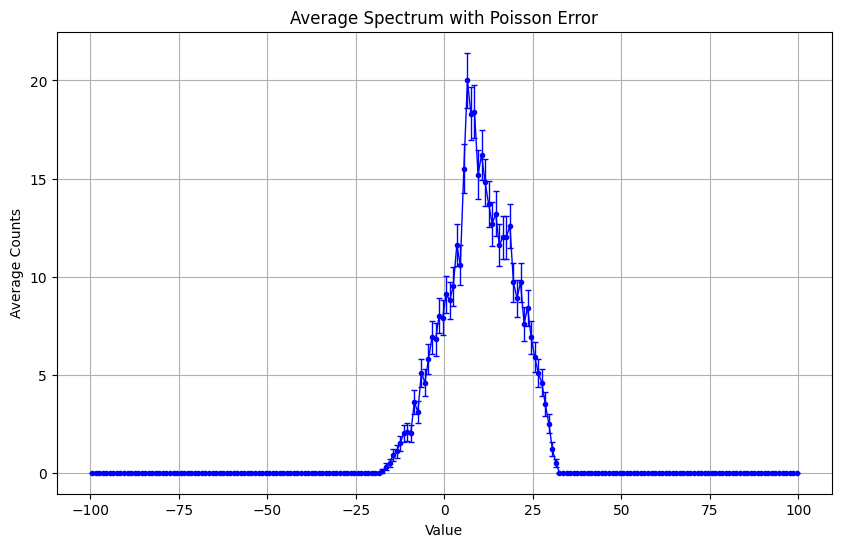

In [55]:
# アクシデンタルの誤差を再考
# 誤差棒の大きさはfrac{\sqrtN}{10}です

import numpy as np
import matplotlib.pyplot as plt

# -250から50まで


# --- 1. 設定パラメータ ---
window_width = 60       # TDiffのウィンドウ幅
start_tdiff = -250      # 開始位置
end_tdiff = 50         # 終了位置

# ヒストグラムの設定（全てのウィンドウで共通にする必要があります）
hist_min = -100
hist_max = 100
bin_width = 1
bins = np.arange(hist_min, hist_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# ヒストグラムデータを格納するリスト
hist_list = []

# --- 2. ループ処理で各範囲のヒストグラムを取得 ---
for t_start in range(start_tdiff, end_tdiff, window_width):
    t_end = t_start + window_width
    
    # データの抽出
    subset = PID_gated[
        (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
    ]
    
    # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
    if len(subset) < 10:
        continue

    # --- 物理量の計算 ---
    GRX_acc = subset['GRX']
    LASX_acc = subset['LASX']
    LASA_acc = subset['LASA']

    # Tp, Tαの計算
    Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
    LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
    T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
    # Variable (S_alpha)
    variable = 392 - Tp_acc - T_alpha_acc_f

    # --- ヒストグラム作成 (カウントのみ取得) ---
    counts, _ = np.histogram(variable, bins=bins)
    
    # リストに追加
    hist_list.append(counts)



#110から410
window_width = 60       # TDiffのウィンドウ幅
start_tdiff = 110      # 開始位置
end_tdiff = 410         # 終了位置

# --- 2. ループ処理で各範囲のヒストグラムを取得 ---
for t_start in range(start_tdiff, end_tdiff, window_width):
    t_end = t_start + window_width
    
    # データの抽出
    subset = PID_gated[
        (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
    ]
    
    # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
    if len(subset) < 10:
        continue

    # --- 物理量の計算 ---
    GRX_acc = subset['GRX']
    LASX_acc = subset['LASX']
    LASA_acc = subset['LASA']

    # Tp, Tαの計算
    Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
    LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
    T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
    # Variable (S_alpha)
    variable = 392 - Tp_acc - T_alpha_acc_f

    # --- ヒストグラム作成 (カウントのみ取得) ---
    counts, _ = np.histogram(variable, bins=bins)
    
    # リストに追加
    hist_list.append(counts)



# --- 3. 平均と誤差の計算 ---

# リストをNumPy配列（行列）に変換
# 行: 各TDiffウィンドウ, 列: 各ビン
hist_matrix = np.array(hist_list)

# # 平均スペクトル
mean_spectrum = np.mean(hist_matrix, axis=0)
summed_spectrum = np.sum(hist_matrix, axis=0)
error = np.sqrt(summed_spectrum) / 10

# --- 4. プロット ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(bin_centers, mean_spectrum, yerr=error, 
                fmt='-o', markersize=3, capsize=2, linewidth=1, color='blue',
                label='Averaged Spectrum ± StdDev')
    
#     # 参考までに個別のスペクトルを薄く表示（ばらつき具合を目視するため）
# for i in range(10):
#     ax.step(bin_centers, hist_matrix[i], where='mid', color='gray', alpha=0.5, linewidth=0.5)

#     ax.set_xlabel('$S_\\alpha$ Value')
#     ax.set_ylabel('Average Counts')
#     ax.set_title(f'Averaged Spectrum over 10 Time Windows')
#     ax.set_ylim(0, 200)
#     ax.grid(True)
#     ax.legend()
    
#     plt.show()

# else:
#     print("No valid data found in the specified ranges.")



ax.set_xlabel('Value')
ax.set_ylabel('Average Counts')
ax.set_title('Average Spectrum with Poisson Error')
ax.grid(True)
# ax.legend()

plt.show()

In [56]:
summed_spectrum

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   1,   3,   5,   9,  11,  15,  20,  21,  20,
        36,  31,  51,  46,  58,  69,  68,  80,  79,  91,  88,  95, 116,
       106, 155, 200, 183, 184, 152, 162, 148, 137, 127, 132, 116, 120,
       120, 126,  97,  89,  97,  76,  84,  69,  59,  51,  46,  35,  25,
        12,   5,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

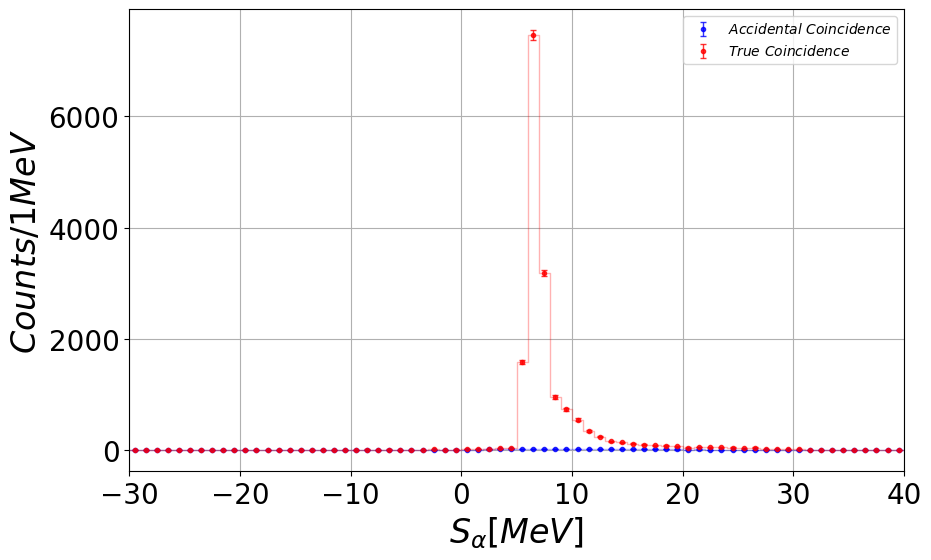

In [57]:
#便宜的に
N_samples = 10

# --- 3. プロット ---
fig, ax = plt.subplots(figsize=(10, 6))

# (A) hist_list1 (BG Mean) の描画
ax.errorbar(bin_centers, mean_spectrum, yerr=error, 
            fmt='o', markersize=3, capsize=2, linewidth=1, color='blue', alpha=0.8,
            label=r'$Accidental{\ }Coincidence$')

ax.tick_params(axis='both', labelsize=20)
# 視認用ライン
ax.step(bin_centers, mean_spectrum, where='mid', color='blue', alpha=0.3, linewidth=1)


# (B) hist_list2 (Target) の描画
ax.errorbar(bin_centers, hist_list2[0], yerr=error2, 
            fmt='o', markersize=3, capsize=2, linewidth=1, color='red', alpha=0.8,
            label=r'$True{\ }Coincidence$')
# 視認用ライン
ax.step(bin_centers, hist_list2[0], where='mid', color='red', alpha=0.3, linewidth=1)


# グラフの設定
ax.set_xlabel(r'$S_\alpha[MeV]$', fontsize=24)
ax.set_ylabel(r'$Counts/1MeV$', fontsize=24)
# ax.set_title('aaa')
ax.set_xlim(-30, 40)
ax.legend()
ax.grid(True)

plt.show()

In [58]:
bin_centers

array([-99.5, -98.5, -97.5, -96.5, -95.5, -94.5, -93.5, -92.5, -91.5,
       -90.5, -89.5, -88.5, -87.5, -86.5, -85.5, -84.5, -83.5, -82.5,
       -81.5, -80.5, -79.5, -78.5, -77.5, -76.5, -75.5, -74.5, -73.5,
       -72.5, -71.5, -70.5, -69.5, -68.5, -67.5, -66.5, -65.5, -64.5,
       -63.5, -62.5, -61.5, -60.5, -59.5, -58.5, -57.5, -56.5, -55.5,
       -54.5, -53.5, -52.5, -51.5, -50.5, -49.5, -48.5, -47.5, -46.5,
       -45.5, -44.5, -43.5, -42.5, -41.5, -40.5, -39.5, -38.5, -37.5,
       -36.5, -35.5, -34.5, -33.5, -32.5, -31.5, -30.5, -29.5, -28.5,
       -27.5, -26.5, -25.5, -24.5, -23.5, -22.5, -21.5, -20.5, -19.5,
       -18.5, -17.5, -16.5, -15.5, -14.5, -13.5, -12.5, -11.5, -10.5,
        -9.5,  -8.5,  -7.5,  -6.5,  -5.5,  -4.5,  -3.5,  -2.5,  -1.5,
        -0.5,   0.5,   1.5,   2.5,   3.5,   4.5,   5.5,   6.5,   7.5,
         8.5,   9.5,  10.5,  11.5,  12.5,  13.5,  14.5,  15.5,  16.5,
        17.5,  18.5,  19.5,  20.5,  21.5,  22.5,  23.5,  24.5,  25.5,
        26.5,  27.5,

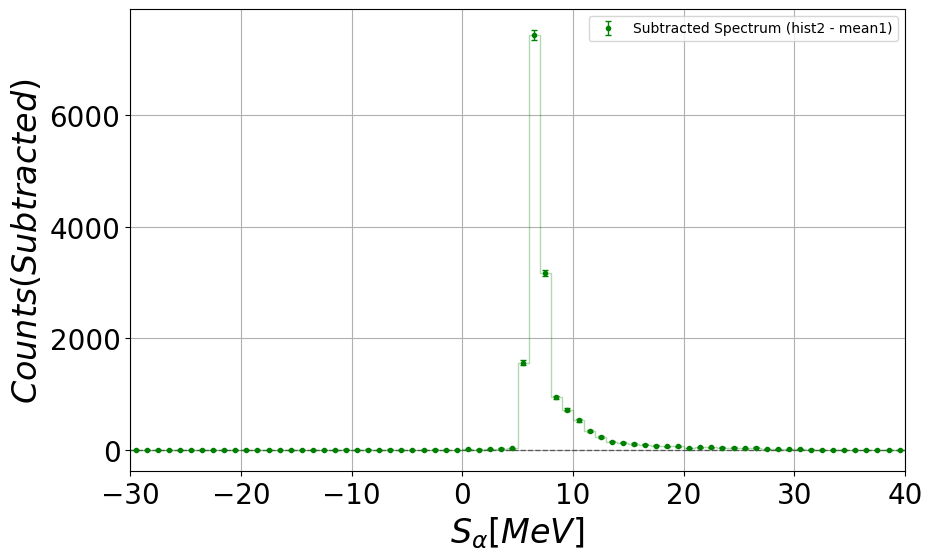

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# --- データの準備 (既存の変数を使用する前提) ---
# hist_list1: [array([counts...]), ...] (バックグラウンド用の複数のスペクトル)
# hist_list2: array([counts...]) (ターゲットの単一スペクトル)
# bin_centers: ビンの中心座標

# NumPy配列化
hist_matrix1 = np.array(hist_list)
y_data2 = np.array(hist_list2).flatten() # 1次元化

# --- 1. hist_list1 (平均) の計算 ---
N_samples = hist_matrix1.shape[0] # 積み上げたサンプル数
mean1 = np.mean(hist_matrix1, axis=0) # 平均値
std1 = np.std(hist_matrix1, axis=0, ddof=1) # 標準偏差
err1 = std1 / np.sqrt(N_samples) # 平均値の標準誤差 (SEM)

# --- 2. hist_list2 の誤差計算 ---
# カウント数のルート (ポアソン誤差)
# 負の値や0が入る可能性も考慮して絶対値をとるか、最小値を設定することがあるが、
# 通常は単純に sqrt(counts) で計算
error2 = np.sqrt(y_data2)

# --- 3. 引き算と誤差伝播 ---
diff_spectrum = y_data2 - mean1

# 誤差の合成 (二乗和のルート)
diff_error = np.sqrt(error2**2 + error**2)


# --- 4. プロット ---
fig, ax = plt.subplots(figsize=(10, 6))

# 0のライン（基準線）を引く
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# 引き算した結果をプロット
ax.errorbar(bin_centers, diff_spectrum, yerr=diff_error,
            fmt='o', markersize=3, capsize=2, linewidth=1, color='green',
            label='Subtracted Spectrum (hist2 - mean1)')
ax.tick_params(axis='both', labelsize=20)
# ステップ状の線も薄く重ねて形状を見やすくする
ax.step(bin_centers, diff_spectrum, where='mid', color='green', alpha=0.3, linewidth=1)

ax.set_xlabel(r'$S_{\alpha}[MeV]$', fontsize=24)
ax.set_ylabel(r'$Counts (Subtracted)$', fontsize=24)
# ax.set_title('Difference Spectrum with Error Propagation')
ax.set_xlim(-30,40)
ax.legend()
ax.grid(True)

plt.show()